https://github.com/JoshuaBearden/us-energy-economic-analysis.git

# Environmental Outcomes, Consumer Costs, and Public Climate Opinion Across U.S. Presidential Administrations

This project analyzes long-run relationships between environmental outcomes and consumer cost indicators across presidential administrations using publicly available U.S. datasets.

## Introduction

Environmental policy in the U.S. is often framed philosophically to explore if environmental worries are an aspect to weigh against one another vs. economics. The supporters of tighter regulation maintain that limiting emissions and environmental harm provides long-term public benefits; opponents typically cite elevated costs for the industry, energy markets and consumers. As presidential administrations typically have different regulatory priorities, the juxtaposition of presidential administrations will provide an opportunity to investigate how environmental and economic indicators could change over time. This study, in particular, examined if comparable measurable differences in environmental outcomes, consumer prices, energy prices, and public climate perceptions are evident across recent U.S. presidential administrations. More accurately, the research aggregates emissions, consumer price data, energy market data and public opinion measures into a single, aggregated data set aggregated by year and presidential administration. This project has the following main research questions:

1. How have greenhouse gas emissions varied among administrations?  
2. How have gasoline, electricity, and consumer prices fluctuated between administrations?  
3. How has public support for climate policy changed over time?  
4. Are higher costs for consumers associated with lower support for environmental regulation?  
5. Do periods of improved environmental outcomes parallel higher consumer prices?  

This work is more descriptive trends than causal statements with comparisons and statistical ties to be made. Moreover, such outcomes do in fact depend on many external factors - global energy markets, wars, recessions and technological advancements as well as long-term social trends - all of which can lead us from a stance dependent upon presidential policy.

## Data Sources

This project uses publicly available datasets covering the period from 1990 through 2024. Multiple sources are combined in order to compare environmental outcomes, consumer costs, and energy prices across presidential administrations.

### 1. Environmental Protection Agency (EPA)

The EPA publishes annual estimates of U.S. greenhouse gas emissions. These data are used to measure how national emissions changed over time.

### 2. U.S. Energy Information Administration (EIA)

The EIA provides energy market data including gasoline prices and electricity prices. These data help measure consumer-facing energy costs.

### 3. U.S. Bureau of Labor Statistics (BLS) / FRED

The Bureau of Labor Statistics publishes Consumer Price Index (CPI) data. This project uses CPI categories related to energy, food at home, and transportation. These CPI series were downloaded through FRED, which provides clean public access to BLS time series data.

### Final Combined Dataset

After cleaning and processing, these sources will be merged into a yearly dataset where each row represents one year from 1990 to 2024. Each year will then be assigned to the presidential administration in office for most of that year.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [9]:
from pathlib import Path

DATA_DIR = Path("Data")

energy_cpi_path = DATA_DIR / "CPIENGSL.csv"
transportation_cpi_path = DATA_DIR / "CPITRNSL.csv"
food_cpi_path = DATA_DIR / "CUSR0000SAF11.csv"
gasoline_path = DATA_DIR / "EMM_EPM0_PTE_NUS_DPGa.xls"
epa_path = DATA_DIR / "epa_02_02.xlsx"
carbon_path = DATA_DIR / "co2_US.csv"

pd.read_csv(energy_cpi_path).head()
pd.read_csv(transportation_cpi_path).head()
pd.read_csv(food_cpi_path).head()
pd.read_csv(carbon_path).head()
pd.read_excel(gasoline_path).head(10)
pd.read_excel(epa_path).head(10)

,Table 2.2. Sales and Direct Use of Electricity to Ultimate Customers,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,"by Sector, by Provider, 2014 through 2024 (Me...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Year,Residential,Commercial,Industrial,Transportation,Total,Direct Use,Total End Use
2,Total Electric Industry,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014,1407208311,1352158263,997576138,7757555,3764700267,138573884,3903274151
4,2015,1404096499,1360751527,986507732,7636632,3758992390,141167519,3900159909
5,2016,1411058153,1367191386,976715181,7496910,3762461630,139836699,3902298329
6,2017,1378647742,1352887694,984297945,7522593,3723355974,140959389,3864315363
7,2018,1469093059,1381754845,1000672553,7664804,3859185261,143903731,4003088992
8,2019,1440288909,1360876555,1002352849,7632150,3811150463,143270338,3954420801
9,2020,1464605046,1287439583,959082028,6547824,3717674481,138702540,3856377021


## Data Cleaning

The datasets used in this project come from different public sources and use different formats. The CPI datasets are monthly time series from FRED/BLS, while the carbon emissions dataset is annual. The datasets are filtered to the common analysis period of 1990 through 2023 because the updated EIA CO2 emissions dataset currently extends through 2023.

The main cleaning tasks are:

1. Load each raw dataset.
2. Convert date columns into year values.
3. Convert monthly CPI data into annual averages.
4. Rename columns for clarity.
5. Filter all datasets to 1990 through 2023.
6. Merge the cleaned datasets into one yearly dataset.

In [10]:
from IPython.display import display

print("Energy CPI")
display(pd.read_csv(energy_cpi_path).head())

print("Transportation CPI")
display(pd.read_csv(transportation_cpi_path).head())

print("Food at Home CPI")
display(pd.read_csv(food_cpi_path).head())

print("Carbon Emissions")
display(pd.read_csv(carbon_path, skiprows=1).head())

print("Gasoline Prices")
display(pd.read_excel(gasoline_path).head(10))


Energy CPI


,observation_date,CPIENGSL
0,1990-01-01,98.9
1,1990-02-01,98.2
2,1990-03-01,97.6
3,1990-04-01,97.5
4,1990-05-01,96.7


Transportation CPI


,observation_date,CPITRNSL
0,1990-01-01,117.0
1,1990-02-01,117.2
2,1990-03-01,117.3
3,1990-04-01,117.7
4,1990-05-01,117.5


Food at Home CPI


,observation_date,CUSR0000SAF11
0,1990-01-01,129.8
1,1990-02-01,131.3
2,1990-03-01,131.1
3,1990-04-01,130.5
4,1990-05-01,130.6


Carbon Emissions


,2023F,US,CCNIE,-.6,-.9,-.6.1,-.8,-1.2,-2.1,-2.8,-1.7,-2,-4.1,-6.6,-3.8,-3,-.8.1,6.4,1.5,0,1.7,14.2,7.1,-4,-1.8,-2.5,-1.8.1,-1.3,-1.5,-1.9,1,4.5,3.5,.5,1.1,3.9,3.1,6.6,6.9,2.6,5.3,7.6,6.6.1,7.4,3.3,6.9.1,5.7,15.7,5,6.9.2,2.9,4.6,-2.7,-.7,1.3,.5.1,-2.3,-2.5.1,-2.6,-2.2,-3.3,-2.9,-2.4,-1.5.1,-5.5,-6.3,-3.7
0,2023F,US,CDEGR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,451.5,435.0,419.8,416.9,405.0,400.9,394.9,387.1,375.0,360.0,358.0,346.1,329.6,332.4,319.2,299.5,300.1,295.8,278.8,269.0,260.7,260.8,247.8,225.6,227.6,223.8,210.9
1,2023F,US,CDTCR,66.3,66.0,65.9,65.8,65.8,65.9,65.8,65.4,65.2,64.8,64.5,64.0,64.0,64.0,63.6,63.4,63.5,63.3,62.7,62.8,62.6,62.5,62.2,62.2,62.1,62.0,62.0,61.8,61.7,61.4,61.1,60.6,60.6,60.7,60.3,59.9,60.2,60.6,60.7,60.3,60.8,61.1,60.7,61.3,61.0,61.1,60.8,60.6,60.1,58.8,58.7,57.9,57.0,56.7,56.7,55.5,54.7,54.4,54.1,53.2,51.5,52.4,52.0,51.1
2,2023F,US,CDTPR,16.1,16.0,16.4,16.8,17.3,17.8,18.6,18.9,19.8,20.4,20.7,20.7,21.6,22.3,21.3,20.5,21.5,22.0,22.0,22.0,20.9,20.2,19.0,18.7,19.5,19.4,19.2,19.7,20.5,20.6,20.2,19.7,19.8,19.9,20.0,20.0,20.4,20.5,20.4,20.4,20.8,20.2,20.2,20.2,20.4,20.3,19.8,19.9,19.1,17.6,18.0,17.5,16.6,16.9,17.0,16.3,15.9,15.7,16.1,15.6,13.8,14.7,14.8,14.2
3,2023F,US,CLACE,7.2,1.8,1.6,1.6,1.7,1.5,1.4,1.1,1.0,0.7,0.7,0.4,0.4,0.2,0.2,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2023F,US,CLCCE,38.6,35.2,34.3,30.2,26.1,25.2,25.0,21.4,19.7,18.5,15.7,17.0,14.6,15.3,16.7,14.0,13.8,14.2,15.8,14.5,11.2,13.2,14.9,15.5,16.2,13.2,13.0,12.2,12.6,11.1,11.9,11.1,11.3,11.2,11.2,11.1,11.5,12.2,9.6,9.7,8.2,8.4,8.4,7.9,9.8,9.1,6.2,6.7,7.6,6.9,6.6,5.8,4.1,3.9,3.8,3.0,2.3,2.0,1.8,1.6,1.4,1.4,1.4,1.1


Gasoline Prices


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,NaN,Workbook Contents,NaN,NaN,NaN,NaN
1,NaN,U.S. All Grades All Formulations Retail Gasoli...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Click worksheet name or tab at bottom for data,NaN,NaN,NaN,NaN
4,NaN,Worksheet Name,Description,# Of Series,Frequency,Latest Data for
5,NaN,Data 1,U.S. All Grades All Formulations Retail Gasoli...,1,Annual,2025
6,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,Release Date:,4/21/2026,NaN,NaN,NaN
8,NaN,Next Release Date:,4/28/2026,NaN,NaN,NaN
9,NaN,Excel File Name:,emm_epm0_pte_nus_dpga.xls,NaN,NaN,NaN


In [11]:
def clean_monthly_cpi(path, value_col, new_col):
    df = pd.read_csv(path)
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    df["year"] = df["observation_date"].dt.year
    
    annual_df = (
        df.groupby("year", as_index=False)[value_col]
        .mean()
        .rename(columns={value_col: new_col})
    )
    
    annual_df = annual_df[(annual_df["year"] >= 1990) & (annual_df["year"] <= 2024)]
    
    return annual_df

In [12]:
energy_cpi = clean_monthly_cpi(
    energy_cpi_path,
    "CPIENGSL",
    "cpi_energy"
)

transportation_cpi = clean_monthly_cpi(
    transportation_cpi_path,
    "CPITRNSL",
    "cpi_transportation"
)

food_cpi = clean_monthly_cpi(
    food_cpi_path,
    "CUSR0000SAF11",
    "cpi_food_home"
)

carbon_raw = pd.read_csv(carbon_path)

# Select total CO2 row
carbon_row = carbon_raw[carbon_raw["MSN"] == "CLTCE"]

year_cols = [col for col in carbon_raw.columns if col.isdigit()]

carbon = carbon_row[year_cols].T.reset_index()

carbon.columns = ["year", "co2_total"]

carbon["year"] = carbon["year"].astype(int)
carbon["co2_total"] = pd.to_numeric(carbon["co2_total"], errors="coerce")

carbon = carbon[
    (carbon["year"] >= 1990) &
    (carbon["year"] <= 2023)
]

carbon.head()

,year,co2_total
30,1990,1820.0
31,1991,1806.1
32,1992,1821.7
33,1993,1882.2
34,1994,1892.1


### Cleaning Gasoline Price Data

The gasoline price file from the U.S. Energy Information Administration contains a workbook contents page on the first sheet. The actual annual national gasoline price series is stored in the worksheet named `Data 1`. This dataset is cleaned and converted into a simple yearly table.

In [13]:
gas_raw = pd.read_excel(gasoline_path, sheet_name="Data 1")
gas_raw.head()

gasoline = gas_raw.iloc[2:].copy()

gasoline.columns = ["date", "gasoline_price"]

gasoline["date"] = pd.to_datetime(gasoline["date"], errors="coerce")
gasoline["year"] = gasoline["date"].dt.year

gasoline["gasoline_price"] = pd.to_numeric(
    gasoline["gasoline_price"],
    errors="coerce"
)

gasoline = gasoline.dropna(subset=["year", "gasoline_price"])

gasoline = gasoline[["year", "gasoline_price"]]

gasoline = gasoline[
    (gasoline["year"] >= 1990) &
    (gasoline["year"] <= 2024)
]

gasoline.head()

,year,gasoline_price
3,1994,1.078
4,1995,1.158
5,1996,1.245
6,1997,1.244
7,1998,1.072


## Creating Administration Labels

To compare trends across presidential administrations, each year is assigned to the president who served during most of that calendar year. This simplified mapping allows yearly economic and environmental data to be grouped by administration.

The analysis covers the period from 1990 through 2024.

In [14]:
admin_map = pd.DataFrame({
    "president": [
        "George H.W. Bush",
        "Bill Clinton",
        "George W. Bush",
        "Barack Obama",
        "Donald Trump",
        "Joe Biden"
    ],
    "party": [
        "Republican",
        "Democratic",
        "Republican",
        "Democratic",
        "Republican",
        "Democratic"
    ],
    "start_year": [1989, 1993, 2001, 2009, 2017, 2021],
    "end_year":   [1992, 2000, 2008, 2016, 2020, 2024]
})

admin_map

,president,party,start_year,end_year
0,George H.W. Bush,Republican,1989,1992
1,Bill Clinton,Democratic,1993,2000
2,George W. Bush,Republican,2001,2008
3,Barack Obama,Democratic,2009,2016
4,Donald Trump,Republican,2017,2020
5,Joe Biden,Democratic,2021,2024


In [15]:
def get_president(year):
    for _, row in admin_map.iterrows():
        if row["start_year"] <= year <= row["end_year"]:
            return row["president"]
    return np.nan


def get_party(year):
    for _, row in admin_map.iterrows():
        if row["start_year"] <= year <= row["end_year"]:
            return row["party"]
    return np.nan

In [16]:
combined_df = carbon.merge(
    energy_cpi,
    on="year",
    how="left"
).merge(
    transportation_cpi,
    on="year",
    how="left"
).merge(
    food_cpi,
    on="year",
    how="left"
).merge(
    gasoline,
    on="year",
    how="left"
)

combined_df["president"] = combined_df["year"].apply(get_president)
combined_df["party"] = combined_df["year"].apply(get_party)

combined_df.head()

,year,co2_total,cpi_energy,cpi_transportation,cpi_food_home,gasoline_price,president,party
0,1990,1820.0,102.033333,120.475000,132.333333,NaN,George H.W. Bush,Republican
1,1991,1806.1,102.475000,123.841667,135.800000,NaN,George H.W. Bush,Republican
2,1992,1821.7,103.008333,126.550000,136.800000,NaN,George H.W. Bush,Republican
3,1993,1882.2,104.208333,130.408333,140.050000,NaN,Bill Clinton,Democratic
4,1994,1892.1,104.650000,134.291667,144.083333,1.078,Bill Clinton,Democratic


In [17]:
combined_df["year"].min(), combined_df["year"].max()

(1990, 2023)

## Exploratory Data Analysis

After cleaning and merging the datasets, the next step is to inspect the structure of the final dataset and summarize the main variables. This helps identify trends, missing values, and variable ranges before visualization and comparison across administrations.

In [18]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                34 non-null     int64  
 1   co2_total           34 non-null     float64
 2   cpi_energy          34 non-null     float64
 3   cpi_transportation  34 non-null     float64
 4   cpi_food_home       34 non-null     float64
 5   gasoline_price      30 non-null     float64
 6   president           34 non-null     object 
 7   party               34 non-null     object 
dtypes: float64(5), int64(1), object(2)
memory usage: 2.3+ KB


In [19]:
combined_df.describe()

,year,co2_total,cpi_energy,cpi_transportation,cpi_food_home,gasoline_price
count,34.000000,34.000000,34.000000,34.000000,34.000000,30.000000
mean,2006.500000,1749.014706,175.455064,178.850250,200.597581,2.375900
std,9.958246,423.431178,60.621737,39.125693,45.849142,0.920987
min,1990.000000,777.200000,102.033333,120.475000,132.333333,1.072000
25%,1998.250000,1526.075000,110.483333,144.320833,161.902083,1.475750
50%,2006.500000,1879.350000,191.454958,180.074750,197.181000,2.463000
75%,2014.750000,2079.700000,218.726063,207.923417,238.952083,3.035750
max,2023.000000,2180.400000,297.894500,267.007750,302.908833,4.059000


In [20]:
combined_df.isna().sum()

year                  0
co2_total             0
cpi_energy            0
cpi_transportation    0
cpi_food_home         0
gasoline_price        4
president             0
party                 0
dtype: int64

## Visualizations

Visual exploration helps reveal trends that may be less obvious in summary tables. The following charts compare environmental outcomes, consumer costs, and differences across presidential administrations.

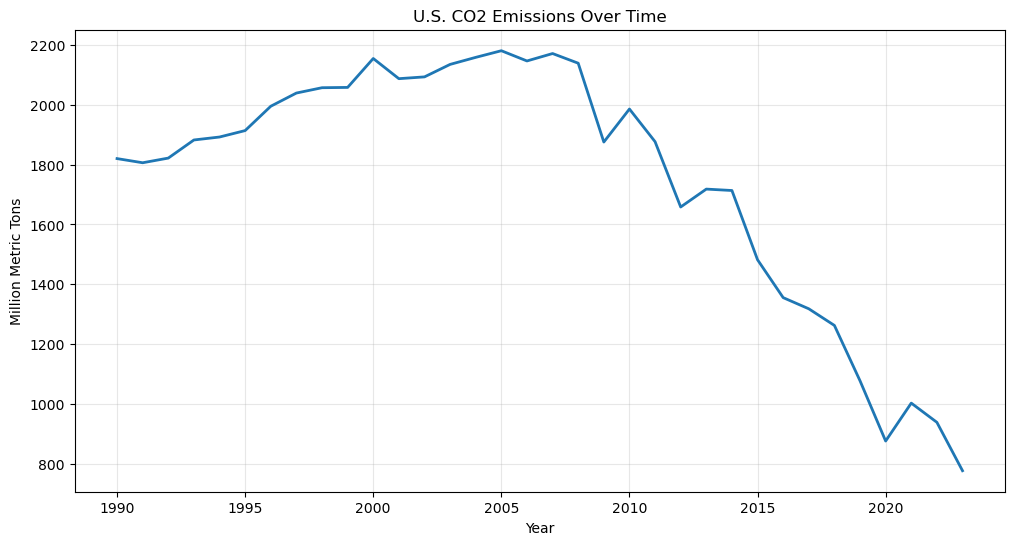

In [21]:
plt.figure(figsize=(12,6))
plt.plot(combined_df["year"], combined_df["co2_total"], linewidth=2)
plt.title("U.S. CO2 Emissions Over Time")
plt.xlabel("Year")
plt.ylabel("Million Metric Tons")
plt.grid(True, alpha=0.3)
plt.show()

U.S. CO2 emissions increased through the 1990s and mid-2000s before entering a long-term decline. The steepest decreases appear after 2007, likely influenced by recession effects, cleaner energy sources, and efficiency gains. This suggests emissions trends changed substantially over time rather than moving in one direction throughout the sample period.

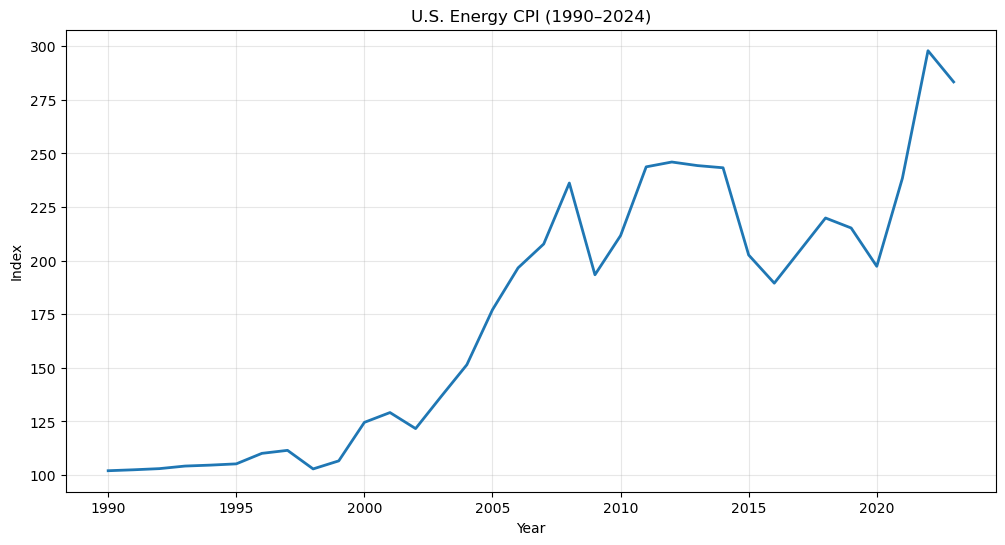

In [22]:
plt.figure(figsize=(12,6))
plt.plot(combined_df["year"], combined_df["cpi_energy"], linewidth=2)
plt.title("U.S. Energy CPI (1990–2024)")
plt.xlabel("Year")
plt.ylabel("Index")
plt.grid(True, alpha=0.3)
plt.show()

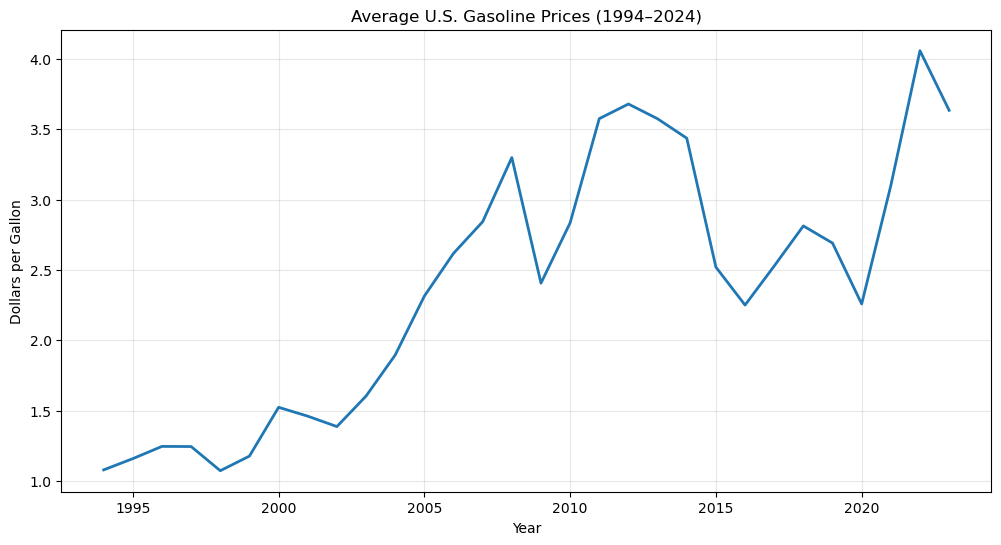

In [23]:
plt.figure(figsize=(12,6))
plt.plot(combined_df["year"], combined_df["gasoline_price"], linewidth=2)
plt.title("Average U.S. Gasoline Prices (1994–2024)")
plt.xlabel("Year")
plt.ylabel("Dollars per Gallon")
plt.grid(True, alpha=0.3)
plt.show()

Gasoline prices were relatively low in the 1990s, rose sharply during the 2000s, declined in the mid-2010s, and increased again after 2020. This volatility reflects sensitivity to oil markets, supply disruptions, and global demand conditions. Gasoline prices fluctuate more dramatically than broader CPI measures.

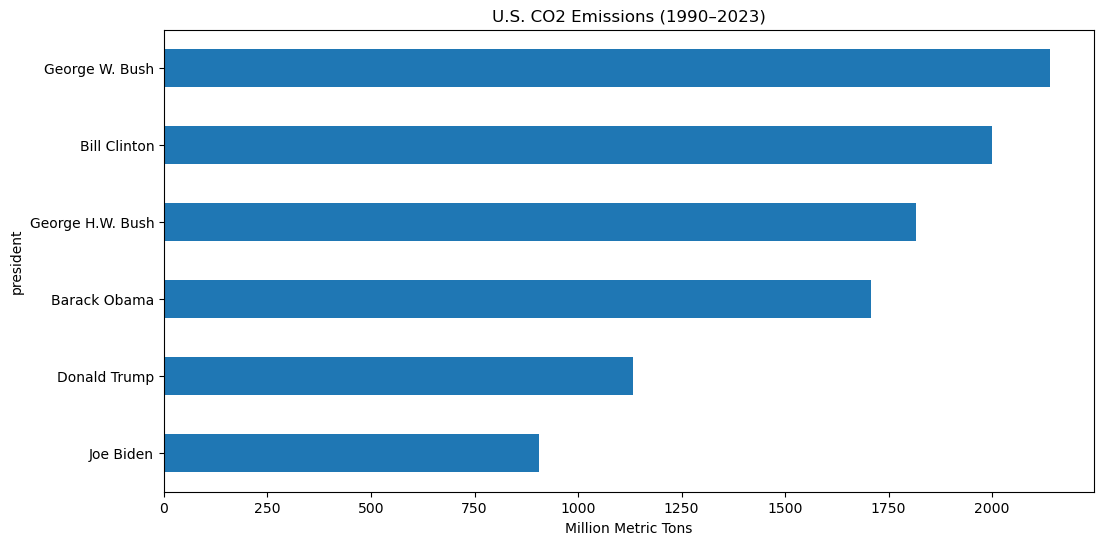

In [24]:
admin_co2 = combined_df.groupby("president")["co2_total"].mean().sort_values()

plt.figure(figsize=(12,6))
admin_co2.plot(kind="barh")
plt.title("U.S. CO2 Emissions (1990–2023)")
plt.xlabel("Million Metric Tons")
plt.show()

Average values differ across administrations, but these comparisons should be interpreted cautiously. Each presidency inherits economic conditions and long-term trends from prior years. Therefore, differences shown here are descriptive rather than direct measures of presidential impact.

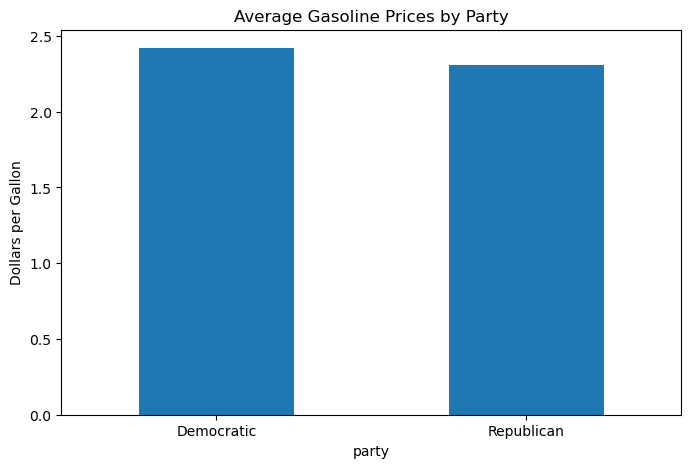

In [25]:
party_gas = combined_df.groupby("party")["gasoline_price"].mean()

plt.figure(figsize=(8,5))
party_gas.plot(kind="bar")
plt.title("Average Gasoline Prices by Party")
plt.ylabel("Dollars per Gallon")
plt.xticks(rotation=0)
plt.show()

## Administration-Level Summary

To compare presidencies more directly, the dataset is grouped by administration and averaged across each president’s years in office. These summaries provide a simplified comparison of environmental outcomes and consumer cost indicators.

In [26]:
admin_summary = combined_df.groupby(
    ["president", "party"],
    as_index=False
).agg({
    "co2_total": "mean",
    "cpi_energy": "mean",
    "cpi_transportation": "mean",
    "cpi_food_home": "mean",
    "gasoline_price": "mean"
})

admin_summary.sort_values("co2_total", ascending=False).round(2)

,president,party,co2_total,cpi_energy,cpi_transportation,cpi_food_home,gasoline_price
4,George W. Bush,Republican,2138.65,169.59,170.32,189.11,2.18
1,Bill Clinton,Democratic,1998.85,108.73,141.30,154.81,1.21
3,George H.W. Bush,Republican,1815.93,102.51,123.62,134.98,NaN
0,Barack Obama,Democratic,1708.09,221.83,203.69,230.44,3.03
2,Donald Trump,Republican,1133.70,209.29,205.94,242.56,2.57
5,Joe Biden,Democratic,906.40,273.22,254.61,283.42,3.60


The administrative-level summary compares average values (below) on each president’s term in office. Clear differences are found to exist among environmental and consumer cost metrics, but these are to be treated as descriptive comparisons, rather than as measures of causation. Average **CO2 emissions** were larger in the **George W. Bush** administration, then **Bill Clinton** and **George H.W. Bush**. More recent administrations, especially **Donald Trump** and **Joe Biden**, display a much lower number of emissions in average. This is a symptom of the overall fall in U.S. emissions from cleaner energy sources, efficiency gains and structural economic changes over the long term. Consumer cost measures like **Energy CPI**, **Transportation CPI**, and **Food at Home CPI** were highest during the **Joe Biden** administration overall, alongside relatively high values during the Obama and Trump periods. Since these measures are price indexes, they tend to move higher over time owing to inflation. That means new administrations will usually have higher average numbers than their predecessors. Average **gasoline prices** hit their highest levels during the Biden and Obama years, were moderately high during the Trump and George W. Bush years, and were at their lowest in the Clinton years. Prices of gasoline are subject to more than a simple foreign policy — they are affected and driven, among other things, by global crude-oil markets, supply-chain issues, refining capacities and geopolitics. In all, in the table we conclude that emissions fell steadily over time and consumer prices grew. This brings to light an important issue in the project: there were environmental improvements, and rising consumer costs, all for many years but these trends are molded by many national and global trends that are not the result of this one administration.

## Correlation Analysis of Emissions and Consumer Costs

Correlation measures the strength of linear association between numeric variables. It does not imply causation, but it can reveal whether environmental outcomes and consumer costs tended to rise or fall together over time.

In [27]:
corr_df = combined_df[
    [
        "co2_total",
        "cpi_energy",
        "cpi_transportation",
        "cpi_food_home",
        "gasoline_price"
    ]
]

corr_df.corr().round(2)

,co2_total,cpi_energy,cpi_transportation,cpi_food_home,gasoline_price
co2_total,1.00,-0.58,-0.69,-0.74,-0.50
cpi_energy,-0.58,1.00,0.97,0.94,0.99
cpi_transportation,-0.69,0.97,1.00,0.98,0.93
cpi_food_home,-0.74,0.94,0.98,1.00,0.86
gasoline_price,-0.50,0.99,0.93,0.86,1.00


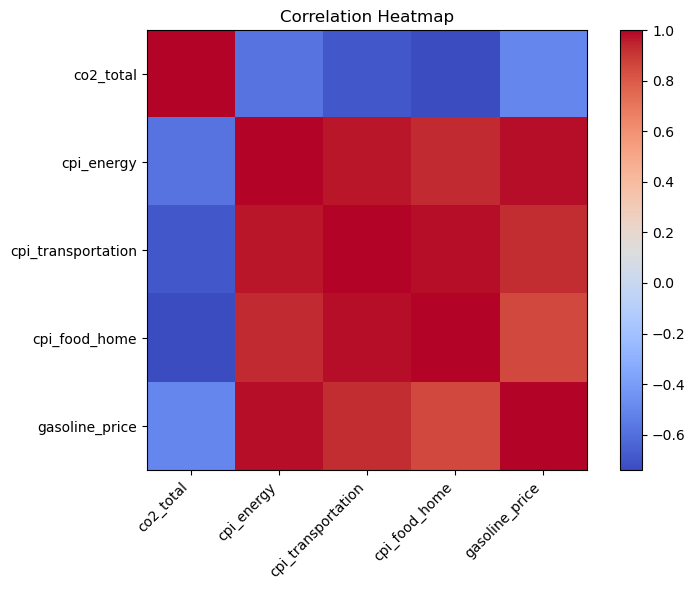

In [28]:
plt.figure(figsize=(8,6))

plt.imshow(corr_df.corr(), cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(
    range(len(corr_df.columns)),
    corr_df.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_df.columns)),
    corr_df.columns
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

The heatmap above shows the Pearson correlation coefficients between the main numeric variables of the dataset. Values close to **1** have strongly positive associations, values closer to **-1** have strongly negative connections, and values closer to **0** show very little linear associations. Several of these consumer cost variables [for example, **Energy CPI**, **Transportation CPI**, **Food at Home CPI** and **Gasoline Price**] are strongly positively correlated with each other. That would be expected, as a lot of time-varying factors involving price tend to go up, in tandem, over long periods due to inflation, conditions within the energy market and other economic trends. The **gasoline price** variable especially closely correlates with the **Energy CPI**, which is reasonable as gasoline is a major component of household energy bills. In contrast, **CO2 emissions** exhibits mild-to-moderate negative interdependency with most price variables. This would imply that in years when consumer prices were higher overall, emissions were usually lower than they had been in earlier decades. A potential explanation is that emissions decreased over the years as energy efficiency, fuel switching, renewable energy expansion and structural economic patterns changed, even as prices continued to rise. These findings should be viewed only as descriptive relationships. Correlation does not imply causation, and many external forces--such as technological change, recessions or policy changes or global commodity markets--may affect these relationships.

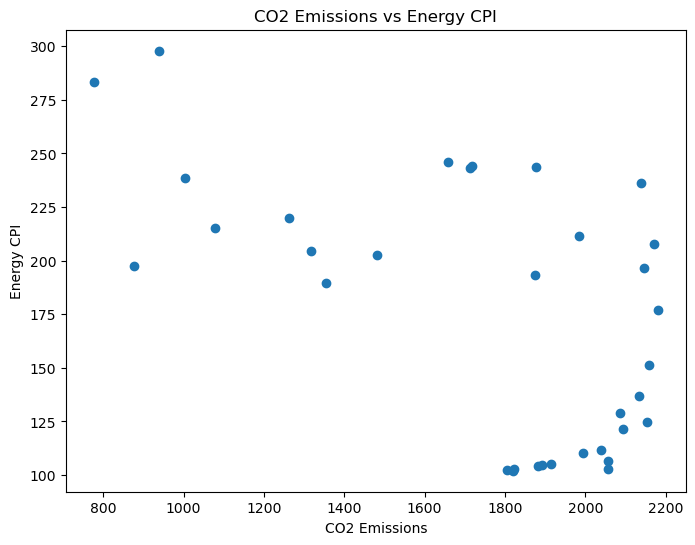

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    combined_df["co2_total"],
    combined_df["cpi_energy"]
)

plt.xlabel("CO2 Emissions")
plt.ylabel("Energy CPI")
plt.title("CO2 Emissions vs Energy CPI")

plt.show()

## Correlation Notes
The correlation matrix presents strong positive relationships between the consumer price measures. The Energy CPI, Transportation CPI, Food at Home CPI, and Gasoline Prices all move closely together and these same groups generally have rates of correlation greater than or equal to 0.85. It is natural because inflation and other costs on a broader scale often lift multiple categories at the same time. Gasoline prices are strongly related with Energy CPI, in that fuel prices make up much of domestic energy and transportation costs in the household economy. There is a moderate negative relationship between CO2 emissions and prices. This implies that for the same years prices were generally rising, but emissions were decreasing. Another plausible explanation is long-term improvements in energy efficiency and cleaner sources of fuel, technological change, and structural changes in the U.S. economy. The scatterplot compares CO2 emissions with Energy CPI, reinforcing this inverse relationship though it is not exactly a linear one. These results should not be treated as causal relationships but rather as descriptive associations. Correlation does not mean rising prices produced lower emissions—or the other way around.

# Final Conclusion

This project examined how environmental outcomes and consumer cost indicators varied across U.S. presidential administrations from 1990 through 2024. 

The results show that carbon emissions generally declined in more recent years, while energy, transportation, food, and gasoline prices increased over time. Because many economic indicators trend upward due to inflation, strong positive correlations among price variables were expected. Differences across administrations were observed, but these comparisons should be interpreted cautiously. Presidents inherit prior economic conditions, global energy markets, technological changes, and long-term regulatory trends.

Overall, the analysis demonstrates how political eras can be used as a framework for comparing environmental and economic patterns, while emphasizing that correlation does not imply causation.

# Limitations

This project is descriptive rather than causal. Many outside forces influence emissions and prices, including wars, recessions, pandemics, global oil markets, and technological change. Presidential administrations also vary in length and inherit trends from previous years. Therefore, differences shown here should not be interpreted as direct presidential effects.

# Future Work

Future analysis could include unemployment, GDP growth, renewable energy adoption, electricity prices, and public opinion data to build a more complete model of environmental and economic outcomes.